In [1]:
import pytensor
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import xarray as xr
import sys
import matplotlib.pyplot as plt
import multiprocessing
import statsmodels.api as sm

In [2]:
np.random.seed(1)

#### Hierarchical (Multilevel) Models

In [3]:
# Defining the population.

n_classes = 8
students_per_class = 30

population_mean = 75
between_class_sd = 8
within_class_sd = 10

print("Number of classes: ", n_classes)
print("Students per class: ", students_per_class)

Number of classes:  8
Students per class:  30


In [4]:
# Simulating the true class means.

class_means = np.random.normal(loc=population_mean, scale=between_class_sd, size=n_classes)

print("True class means: ", np.round(class_means, 2))

# Simulating student scores.

scores = []
classes = []

for i in range(n_classes):

    class_scores = np.random.normal(loc=class_means[i], scale=within_class_sd, size=students_per_class)

    scores.extend(class_scores)
    classes.extend([i + 1] * students_per_class)

# Creating a DataFrame.

data = pd.DataFrame({
    "Class": classes,
    "Score": scores
})

print("First five observations:\n", data.head())

# Computing class summaries.

summary = data.groupby("Class")["Score"].agg(
    ["mean", "std", "count"]
)

print("Class summaries: ", summary)

True class means:  [87.99 70.11 70.77 66.42 81.92 56.59 88.96 68.91]
First five observations:
    Class       Score
0      1   91.185154
1      1   85.501059
2      1  102.615842
3      1   67.393356
4      1   84.770591
Class summaries:              mean        std  count
Class                             
1      86.346534   8.159147     30
2      73.526724   8.322051     30
3      71.342524   8.287986     30
4      67.118893   9.974808     30
5      82.846465   8.725644     30
6      57.860112   9.549219     30
7      89.747670  11.208260     30
8      69.421567  10.215751     30


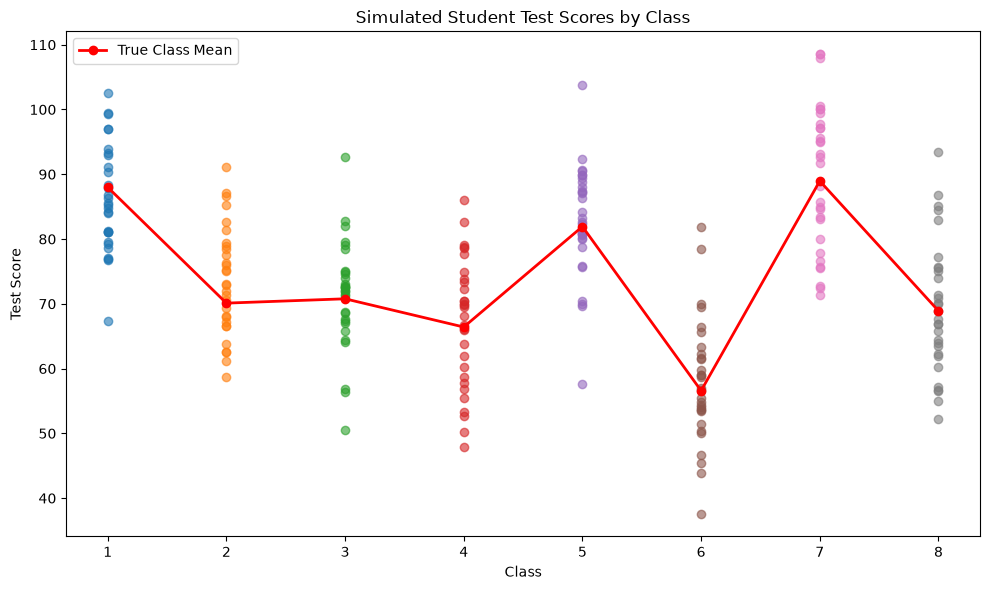

In [5]:
# Visualizing the simulated scores.

plt.figure(figsize=(10, 6))

for i in range(n_classes):

    class_scores = data[data["Class"] == i + 1]["Score"]

    plt.scatter(
        np.repeat(i + 1, len(class_scores)),
        class_scores,
        alpha=0.6
    )

plt.plot(
    np.arange(1, n_classes + 1),
    class_means,
    color="red",
    linewidth=2,
    marker="o",
    label="True Class Mean"
)

plt.title("Simulated Student Test Scores by Class")
plt.xlabel("Class")
plt.ylabel("Test Score")

plt.legend()

plt.tight_layout()

plt.show()

In [6]:
# Defining the population.

n_classes = 8
students_per_class = 30

population_mean = 75
between_class_sd = 8
within_class_sd = 10

# Simulating the true class means.

true_class_means = np.random.normal(loc=population_mean, scale=between_class_sd, size=n_classes)

# Simulating student scores.

scores = []
classes = []

for i in range(n_classes):

    class_scores = np.random.normal(loc=true_class_means[i], scale=within_class_sd, size=students_per_class)

    scores.extend(class_scores)
    classes.extend([i + 1] * students_per_class)

data = pd.DataFrame({
    "Class": classes,
    "Score": scores
})

In [7]:
# Computing observed class means.

observed_means = data.groupby("Class")["Score"].mean().values

# Computing the overall (pooled) mean.

overall_mean = data["Score"].mean()

print("Overall mean: ", round(overall_mean, 2))

# Computing the shrinkage weight.

tau2 = between_class_sd ** 2
sigma2 = within_class_sd ** 2
n = students_per_class

weight = tau2 / (tau2 + sigma2 / n)

print("Shrinkage weight:", round(weight, 3))

# Computing hierarchical estimates.

hierarchical_means = (weight * observed_means + (1 - weight) * overall_mean)

# Displaying results.

results = pd.DataFrame({

    "True Mean": np.round(true_class_means, 2),
    "Observed Mean": np.round(observed_means, 2),
    "Hierarchical Mean": np.round(hierarchical_means, 2)

})

print("\nEstimated Class Means:\n", results)

Overall mean:  73.92
Shrinkage weight: 0.95

Estimated Class Means:
    True Mean  Observed Mean  Hierarchical Mean
0      89.48          91.54              90.67
1      64.55          66.14              66.52
2      72.24          70.19              70.38
3      73.15          72.96              73.00
4      52.66          52.38              53.44
5      90.50          91.30              90.44
6      77.93          79.22              78.96
7      66.64          67.63              67.94


#### Pooled, Unpooled, and Hierarchical Estimates Graphically

In [8]:
# Defining the population.

n_classes = 8
students_per_class = 30

population_mean = 75
between_class_sd = 8
within_class_sd = 10

# Simulating the true class means.

true_class_means = np.random.normal(loc=population_mean, scale=between_class_sd, size=n_classes)

# Simulating student scores.

scores = []
classes = []

for i in range(n_classes):

    class_scores = np.random.normal(loc=true_class_means[i], scale=within_class_sd, size=students_per_class)

    scores.extend(class_scores)
    classes.extend([i + 1] * students_per_class)

data = pd.DataFrame({
    "Class": classes,
    "Score": scores
})

In [9]:
# Computing estimates.

observed_means = data.groupby("Class")["Score"].mean().values

pooled_mean = data["Score"].mean()

tau2 = between_class_sd ** 2
sigma2 = within_class_sd ** 2

weight = tau2 / (tau2 + sigma2 / students_per_class)

hierarchical_means = (weight * observed_means + (1 - weight) * pooled_mean)

# Displaying results.

results = pd.DataFrame({

    "True Mean": np.round(true_class_means, 2),
    "Unpooled Mean": np.round(observed_means, 2),
    "Hierarchical Mean": np.round(hierarchical_means, 2)

})

print(results)

print("\nPooled Mean: ", round(pooled_mean, 2))

   True Mean  Unpooled Mean  Hierarchical Mean
0      79.23          82.38              81.75
1      57.10          55.71              56.40
2      66.14          68.13              68.21
3      74.86          74.56              74.32
4      61.24          61.98              62.36
5      75.46          74.04              73.82
6      68.60          67.90              67.99
7      72.67          72.21              72.08

Pooled Mean:  69.62


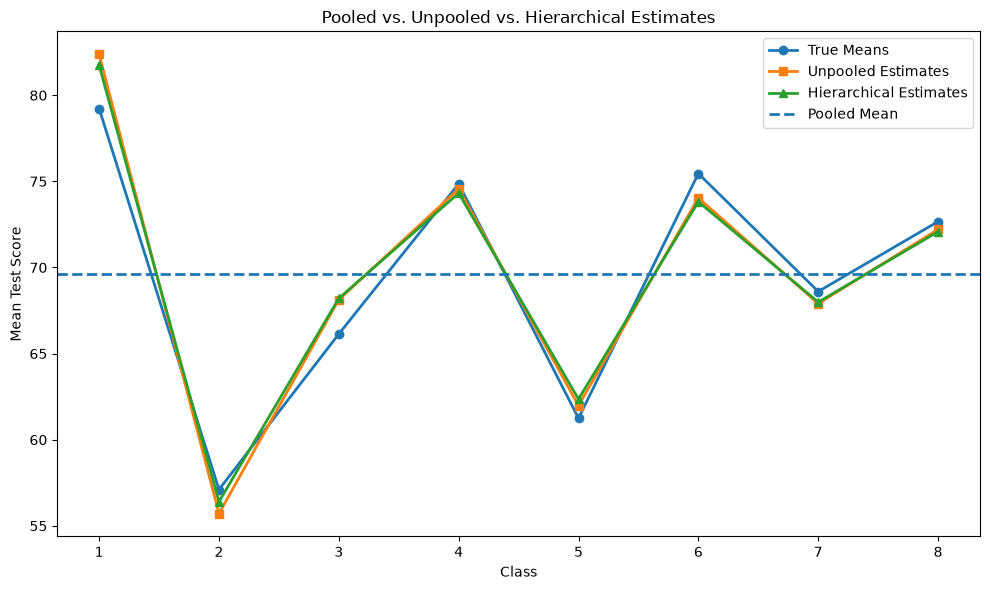

In [10]:
# Visualizing the comparison.

x = np.arange(1, n_classes + 1)

plt.figure(figsize=(10, 6))

plt.plot(
    x,
    true_class_means,
    marker="o",
    linewidth=2,
    label="True Means"
)

plt.plot(
    x,
    observed_means,
    marker="s",
    linewidth=2,
    label="Unpooled Estimates"
)

plt.plot(
    x,
    hierarchical_means,
    marker="^",
    linewidth=2,
    label="Hierarchical Estimates"
)

plt.axhline(
    pooled_mean,
    linestyle="--",
    linewidth=2,
    label="Pooled Mean"
)

plt.title("Pooled vs. Unpooled vs. Hierarchical Estimates")
plt.xlabel("Class")
plt.ylabel("Mean Test Score")


plt.legend()

plt.tight_layout()

plt.show()

#### Hierarchical Bayesian Model in PyMC

In [11]:
# Simulating hierarchical data.

n_classes = 8
students_per_class = 30

true_population_mean = 75
true_between_class_sd = 8
true_within_class_sd = 10

true_class_means = np.random.normal(loc=true_population_mean, scale=true_between_class_sd, size=n_classes)

scores = []
class_index = []

for i in range(n_classes):

    class_scores = np.random.normal(loc=true_class_means[i], scale=true_within_class_sd, size=students_per_class)

    scores.extend(class_scores)
    class_index.extend([i] * students_per_class)

scores = np.array(scores)
class_index = np.array(class_index)

print("Number of classes:", n_classes)
print("Students per class:", students_per_class)

Number of classes: 8
Students per class: 30


In [12]:
# Building the hierarchical Bayesian model.

with pm.Model() as hierarchical_model:

    # Hyperpriors.

    population_mean = pm.Normal(
        "population_mean",
        mu=70,
        sigma=20
    )

    between_class_sd = pm.HalfNormal(
        "between_class_sd",
        sigma=10
    )

    # Group-level priors.

    class_mean = pm.Normal(
        "class_mean",
        mu=population_mean,
        sigma=between_class_sd,
        shape=n_classes
    )

    # Observation-level parameter.

    within_class_sd = pm.HalfNormal(
        "within_class_sd",
        sigma=10
    )

    # Likelihood.

    score = pm.Normal(
        "score",
        mu=class_mean[class_index],
        sigma=within_class_sd,
        observed=scores
    )

    trace = pm.sample(
        draws=2000,
        tune=1000,
        random_seed=42,
        return_inferencedata=True
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [population_mean, between_class_sd, class_mean, within_class_sd]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 3 seconds.


In [14]:
summary = az.summary(
    trace,
    ci_prob=0.95
)

print("Posterior Summary")
print(summary)

Posterior Summary
                   mean     sd eti95_lb eti95_ub ess_bulk ess_tail r_hat mcse_mean mcse_sd
population_mean   76.13   2.76       70       82     8971     5787  1.00      0.03   0.025
class_mean[0]     72.74   1.63       70       76    12560     5934  1.00     0.015   0.011
class_mean[1]     69.37   1.68       66       73    11810     5759  1.00     0.015   0.011
class_mean[2]     81.26   1.62       78       84    10584     6050  1.00     0.016   0.011
class_mean[3]     76.38   1.64       73       80    12992     5815  1.00     0.014    0.01
class_mean[4]     76.99   1.63       74       80    12264     5552  1.00     0.015    0.01
class_mean[5]     71.96   1.66       69       75    11026     6129  1.00     0.016   0.011
class_mean[6]     88.52   1.68       85       92    10797     6153  1.00     0.016   0.012
class_mean[7]     72.27   1.65       69       76    11510     5823  1.00     0.015   0.011
between_class_sd   7.36   2.31      4.2       13     8163     6620  1.00

#### Group-Level Variance and Individual Group Posteriors

In [15]:
# Posterior summary.

summary = pm.stats.summary(trace)

print("Posterior Summary: ", summary)

# Population-level parameters.

print("Population Mean: ",
      summary.loc["population_mean", "mean"])

print("Between-Class SD: ",
      summary.loc["between_class_sd", "mean"])

print("Within-Class SD: ",
      summary.loc["within_class_sd", "mean"])

Posterior Summary:                     mean     sd eti89_lb eti89_ub ess_bulk ess_tail r_hat mcse_mean mcse_sd
population_mean   76.13   2.76       72       80     8971     5787  1.00      0.03   0.025
class_mean[0]     72.74   1.63       70       75    12560     5934  1.00     0.015   0.011
class_mean[1]     69.37   1.68       67       72    11810     5759  1.00     0.015   0.011
class_mean[2]     81.26   1.62       79       84    10584     6050  1.00     0.016   0.011
class_mean[3]     76.38   1.64       74       79    12992     5815  1.00     0.014    0.01
class_mean[4]     76.99   1.63       74       80    12264     5552  1.00     0.015    0.01
class_mean[5]     71.96   1.66       69       75    11026     6129  1.00     0.016   0.011
class_mean[6]     88.52   1.68       86       91    10797     6153  1.00     0.016   0.012
class_mean[7]     72.27   1.65       70       75    11510     5823  1.00     0.015   0.011
between_class_sd   7.36   2.31      4.5       12     8163     6620  1.

In [16]:
# Individual class means.

print("\nIndividual Class Means")

for i in range(8):

    value = float(summary.loc[f"class_mean[{i}]", "mean"])

    print(f"Class {i+1}: {value:.2f}")


Individual Class Means
Class 1: 72.74
Class 2: 69.37
Class 3: 81.26
Class 4: 76.38
Class 5: 76.99
Class 6: 71.96
Class 7: 88.52
Class 8: 72.27


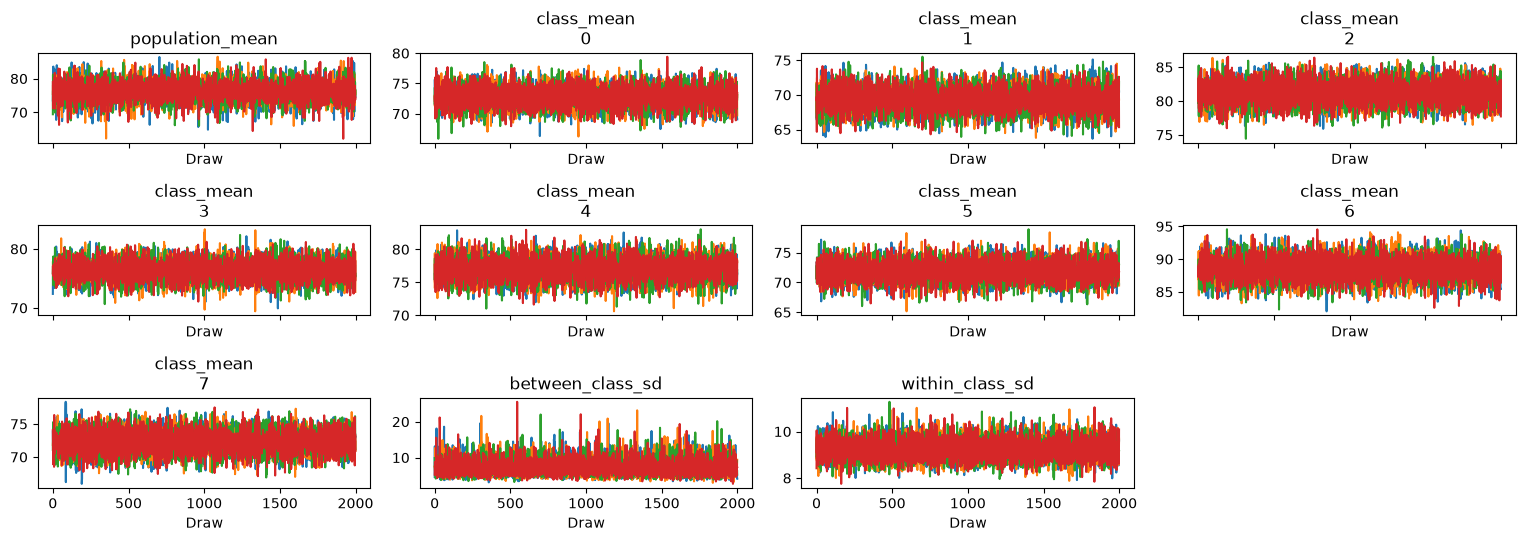

In [17]:
# Posterior distributions of class means.

az.plot_trace(trace)

plt.tight_layout()

plt.show()

#### Shrinkage Effect

In [18]:
# Computing posterior means of the class means.

hierarchical_means = (
    trace.posterior["class_mean"]
    .mean(dim=("chain", "draw"))
    .values
)

# Computing unpooled estimates.

unpooled_means = np.array([
    scores[class_index == i].mean()
    for i in range(n_classes)
])

# Computing the pooled mean.

pooled_mean = scores.mean()

print("True Class Means: ", np.round(true_class_means, 2))
print("Unpooled Means: ", np.round(unpooled_means, 2))
print("Hierarchical Means: ", np.round(hierarchical_means, 2))
print("Overall Mean: ", round(pooled_mean, 2))

True Class Means:  [73.89 69.17 79.25 75.03 77.57 69.2  87.29 75.  ]
Unpooled Means:  [72.49 68.92 81.6  76.38 77.06 71.67 89.3  72.02]
Hierarchical Means:  [72.74 69.37 81.26 76.38 76.99 71.96 88.52 72.27]
Overall Mean:  76.18


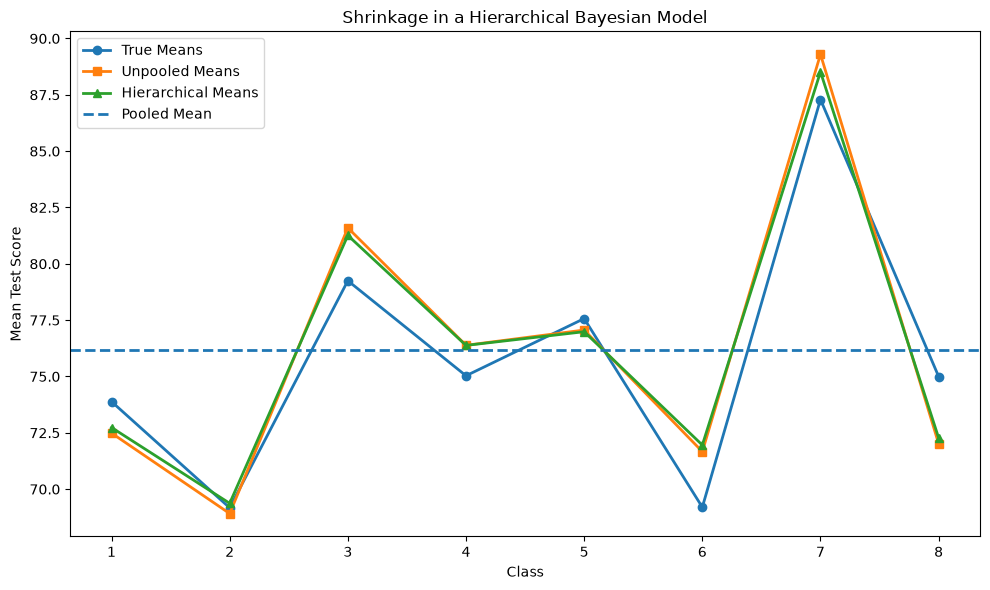

In [19]:
# Visualizing the comparison.

x = np.arange(1, n_classes + 1)

plt.figure(figsize=(10, 6))

plt.plot(
    x,
    true_class_means,
    marker="o",
    linewidth=2,
    label="True Means"
)

plt.plot(
    x,
    unpooled_means,
    marker="s",
    linewidth=2,
    label="Unpooled Means"
)

plt.plot(
    x,
    hierarchical_means,
    marker="^",
    linewidth=2,
    label="Hierarchical Means"
)

plt.axhline(
    pooled_mean,
    linestyle="--",
    linewidth=2,
    label="Pooled Mean"
)

plt.title("Shrinkage in a Hierarchical Bayesian Model")
plt.xlabel("Class")
plt.ylabel("Mean Test Score")

plt.legend()

plt.tight_layout()

plt.show()